# Advanced Spray Chart

Clean notebook for building player spray charts and leaderboard tables from the 2024 + 2025 batted-ball data.


## Load 2025 Data


In [16]:
import pandas as pd

df_2025 = pd.read_parquet(r"E:\Baseball\Data\Savant\2025_Hitters_Bat_Tracking_Full")

print(df_2025.shape)


(709894, 118)


## Build Combined 2024 + 2025 Data


In [17]:

from pybaseball import playerid_reverse_lookup

# Load 2024 and combine it with the already-loaded 2025 data.
df_2024 = pd.read_parquet(r"E:\Baseball\Data\Savant\2024_statcast_full.parquet")
df_all = pd.concat([df_2025, df_2024], ignore_index=True)

# Add batter names so player filters work for df_2025, df_2024, and df_all.
if "batter_name" not in df_all.columns:
    df_all["batter_name"] = pd.NA

missing_names = df_all["batter_name"].isna() & df_all["batter"].notna()
if missing_names.any():
    missing_batter_ids = df_all.loc[missing_names, "batter"].astype(int).unique().tolist()
    lookup_all = playerid_reverse_lookup(missing_batter_ids, key_type="mlbam")
    lookup_all["key_mlbam"] = lookup_all["key_mlbam"].astype(int)
    lookup_all["batter_name"] = lookup_all["name_first"] + " " + lookup_all["name_last"]
    name_map = lookup_all.set_index("key_mlbam")["batter_name"]
    df_all.loc[missing_names, "batter_name"] = df_all.loc[missing_names, "batter"].astype(int).map(name_map)

# Recreate pitch grouping so each season dataframe can be used directly in make_spray_chart.
pitch_map = {
    "Curveball": "Curveball",
    "Knuckle Curve": "Curveball",
    "Slurve": "Curveball",
    "Slow Curve": "Curveball",
}

fastballs = ["4-Seam Fastball", "Sinker", "Cutter"]
offspeed = ["Changeup", "Split-Finger"]

def map_pitch_bucket(p):
    if p in fastballs:
        return "Fastball"
    if p in offspeed:
        return "Offspeed"
    return "Breaking"

df_all["pitch_grouped"] = df_all["pitch_name"].replace(pitch_map)
df_all["pitch_bucket"] = df_all["pitch_grouped"].apply(map_pitch_bucket)

# Keep the single-season dataframes chart-ready too.
df_2025 = df_all[df_all["game_year"].eq(2025)].copy()
df_2024 = df_all[df_all["game_year"].eq(2024)].copy()


## Spray Chart Function


In [18]:

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path
from datetime import datetime
from IPython.display import display
import ipywidgets as widgets

HIT_EVENTS = {"single", "double", "triple", "home_run"}
OUT_EVENTS = {
    "field_out", "force_out", "grounded_into_double_play", "double_play",
    "fielders_choice_out", "fielders_choice", "other_out",
}
RESULT_GROUPS = {
    "All": None,
    "Hits": {"events": HIT_EVENTS},
    "Outs": {"events": OUT_EVENTS},
    "Home Runs": {"events": {"home_run"}},
    "Extra-Base Hits": {"events": {"double", "triple", "home_run"}},
    "Non-HR": {"exclude_events": {"home_run"}},
    "Ground Balls": {"bb_type": {"ground_ball"}},
    "Line Drives": {"bb_type": {"line_drive"}},
    "Fly Balls": {"bb_type": {"fly_ball"}},
    "Popups": {"bb_type": {"popup"}},
}
LAST_SPRAY_CHART = {"fig": None, "context": {}}


def _as_filter_list(value):
    if value is None:
        return None
    if isinstance(value, str):
        text = value.strip()
        if not text or text.lower() == "all":
            return None
        return [v.strip() for v in text.replace(";", ",").split(",") if v.strip()]
    if isinstance(value, (list, tuple, set, pd.Series, np.ndarray)):
        values = list(value)
        return values if values else None
    return [value]


def _apply_result_group_filter(data, result_group="All"):
    if result_group is None or str(result_group).lower() == "all":
        return data
    if result_group not in RESULT_GROUPS:
        raise ValueError(f"result_group must be one of: {', '.join(RESULT_GROUPS)}")
    rule = RESULT_GROUPS[result_group]
    if rule is None:
        return data
    out = data
    if "events" in rule:
        out = out[out["events"].isin(rule["events"])]
    if "exclude_events" in rule:
        out = out[~out["events"].isin(rule["exclude_events"])]
    if "bb_type" in rule:
        out = out[out["bb_type"].isin(rule["bb_type"])]
    return out


def _add_spray_angle_columns(data):
    out = data.copy()
    home_x = 125.42
    home_y = 198.27
    dx = out["hc_x"] - home_x
    dy = home_y - out["hc_y"]
    out["spray_angle"] = np.degrees(np.arctan2(dx, dy))
    stand = out["stand"].astype(str).str.upper() if "stand" in out.columns else pd.Series("", index=out.index)
    out["normalized_spray_angle"] = np.where(stand.eq("L"), -out["spray_angle"], out["spray_angle"])
    out["spray_side"] = np.select(
        [out["normalized_spray_angle"] < 0, out["normalized_spray_angle"] > 0],
        ["Pull", "Oppo"],
        default="Straightaway",
    )
    return out


def _apply_spray_angle_range(data, spray_angle_range=(-45, 45)):
    if spray_angle_range is None:
        return data, None
    if len(spray_angle_range) != 2:
        raise ValueError("spray_angle_range must be a two-value tuple/list like (-45, 45)")
    lo, hi = sorted([float(spray_angle_range[0]), float(spray_angle_range[1])])
    out = data[data["normalized_spray_angle"].between(lo, hi, inclusive="both")].copy()
    return out, (lo, hi)


def make_spray_chart(
    df,
    player="steven kwan",
    balls=None,
    strikes=None,
    pitch_bucket=None,
    pitch_name=None,
    zones=None,
    p_throws="All",
    result_group="All",
    spray_angle_range=(-45, 45),
    squared_up_threshold=80,
):
    sub = df[df["batter_name"].str.lower() == player.lower()].copy()

    if balls is not None:
        sub = sub[sub["balls"].isin(balls if isinstance(balls, list) else [balls])]
    if strikes is not None:
        sub = sub[sub["strikes"].isin(strikes if isinstance(strikes, list) else [strikes])]
    if pitch_bucket is not None:
        sub = sub[sub["pitch_bucket"].isin(pitch_bucket if isinstance(pitch_bucket, list) else [pitch_bucket])]
    if pitch_name is not None:
        sub = sub[sub["pitch_name"].isin(pitch_name if isinstance(pitch_name, list) else [pitch_name])]
    if zones is not None:
        sub = sub[sub["zone"].isin(zones if isinstance(zones, list) else [zones])]

    p_throw_values = _as_filter_list(p_throws)
    if p_throw_values is not None:
        sub = sub[sub["p_throws"].isin(p_throw_values)]

    sub = _apply_result_group_filter(sub, result_group=result_group)
    sub = sub[sub["hc_x"].notna() & sub["hc_y"].notna() & sub["hit_distance_sc"].notna()].copy()
    sub = _add_spray_angle_columns(sub)
    sub, applied_spray_range = _apply_spray_angle_range(sub, spray_angle_range=spray_angle_range)

    distance = sub["hit_distance_sc"]
    sub["field_x"] = distance * np.sin(np.radians(sub["spray_angle"]))
    sub["field_y"] = distance * np.cos(np.radians(sub["spray_angle"]))

    def format_hover_value(col, decimals=1):
        if col in sub.columns:
            return pd.to_numeric(sub[col], errors="coerce").round(decimals).astype(str)
        return pd.Series("nan", index=sub.index)

    contact_col = "intercept_ball_minus_batter_pos_y_inches"
    xba_col = "estimated_ba_using_speedangle"
    xwoba_col = "estimated_woba_using_speedangle"
    if all(col in sub.columns for col in ["launch_speed", "bat_speed", "release_speed"]):
        launch_speed_num = pd.to_numeric(sub["launch_speed"], errors="coerce")
        bat_speed_num = pd.to_numeric(sub["bat_speed"], errors="coerce")
        release_speed_num = pd.to_numeric(sub["release_speed"], errors="coerce")
        sub["pitch_speed_home_proxy"] = 0.92 * release_speed_num
        sub["max_theoretical_ev"] = 1.23 * bat_speed_num + 0.23 * sub["pitch_speed_home_proxy"]
        sub["squared_up_pct"] = launch_speed_num / sub["max_theoretical_ev"]
        sub.loc[sub["max_theoretical_ev"].le(0), "squared_up_pct"] = np.nan
        squared_up_cutoff = float(squared_up_threshold) / 100
        sub["is_squared_up"] = pd.Series(
            np.where(sub["squared_up_pct"].notna(), sub["squared_up_pct"].ge(squared_up_cutoff), pd.NA),
            index=sub.index,
            dtype="object",
        )
    else:
        sub["squared_up_pct"] = np.nan
        sub["is_squared_up"] = pd.NA

    sub["hover_xba"] = format_hover_value(xba_col, decimals=3)
    sub["hover_xwoba"] = format_hover_value(xwoba_col, decimals=3)
    sub["contact_out_in_front"] = format_hover_value(contact_col)
    sub["hover_attack_angle"] = format_hover_value("attack_angle")
    sub["hover_attack_direction"] = format_hover_value("attack_direction")
    sub["hover_swing_path_tilt"] = format_hover_value("swing_path_tilt")
    sub["hover_bat_speed"] = format_hover_value("bat_speed")
    sub["hover_swing_length"] = format_hover_value("swing_length")
    sub["hover_squared_up_pct"] = (sub["squared_up_pct"] * 100).round(1).astype(str)
    sub["hover_squared_up"] = sub["is_squared_up"].map({True: "Yes", False: "No"}).fillna("nan")

    sub["hover"] = (
        "Batter: " + sub["batter_name"].astype(str) +
        "<br>Count: " + sub["balls"].astype(str) + "-" + sub["strikes"].astype(str) +
        "<br>Pitch: " + sub["pitch_name"].astype(str) +
        "<br>Pitcher Throws: " + sub["p_throws"].astype(str) +
        "<br>Zone: " + sub["zone"].astype(str) +
        "<br>xBA: " + sub["hover_xba"] +
        "<br>xWOBA: " + sub["hover_xwoba"] +
        "<br>EV: " + format_hover_value("launch_speed") + " mph" +
        "<br>LA: " + format_hover_value("launch_angle") + " deg" +
        "<br>Distance: " + format_hover_value("hit_distance_sc", decimals=0) + " ft" +
        "<br>Contact Out In Front: " + sub["contact_out_in_front"] + " in" +
        "<br>Attack Angle: " + sub["hover_attack_angle"] + " deg" +
        "<br>Attack Direction: " + sub["hover_attack_direction"] + " deg" +
        "<br>Swing Path Tilt: " + sub["hover_swing_path_tilt"] + " deg" +
        "<br>Bat Speed: " + sub["hover_bat_speed"] + " mph" +
        "<br>Swing Length: " + sub["hover_swing_length"] + " ft" +
        "<br>Spray Angle: " + format_hover_value("normalized_spray_angle") + " deg" +
        "<br>Spray Side: " + sub["spray_side"].astype(str) +
        "<br>Squared-Up %: " + sub["hover_squared_up_pct"] + "%" +
        "<br>Squared Up: " + sub["hover_squared_up"] +
        "<br>Event: " + sub["events"].astype(str)
    )
    if "game_year" in sub.columns:
        sub["hover"] += "<br>Season: " + sub["game_year"].astype(str)

    fig = go.Figure()
    theta = np.linspace(-45, 45, 200)
    wall_dist = np.interp(np.abs(theta), [0, 30, 45], [400, 370, 330])
    fig.add_trace(go.Scatter(x=wall_dist * np.sin(np.radians(theta)), y=wall_dist * np.cos(np.radians(theta)), mode="lines", name="Outfield Fence", line=dict(width=3)))
    for angle in [-45, 45]:
        line_dist = np.interp(abs(angle), [0, 30, 45], [400, 370, 330])
        fig.add_trace(go.Scatter(x=[0, line_dist * np.sin(np.radians(angle))], y=[0, line_dist * np.cos(np.radians(angle))], mode="lines", name="Foul Line", line=dict(width=2, dash="dash"), showlegend=False))
    theta_in = np.linspace(-45, 45, 100)
    fig.add_trace(go.Scatter(x=95 * np.sin(np.radians(theta_in)), y=95 * np.cos(np.radians(theta_in)), mode="lines", name="Infield Dirt", line=dict(width=2)))

    bb_colors = {"ground_ball": "mediumslateblue", "line_drive": "#4cc9f0", "fly_ball": "crimson", "popup": "forestgreen"}
    bb_labels = {"ground_ball": "Ground Ball", "line_drive": "Line Drive", "fly_ball": "Fly Ball", "popup": "Popup"}
    bb_order = ["ground_ball", "line_drive", "fly_ball", "popup"]
    remaining_bb = [bb for bb in sub["bb_type"].dropna().unique() if bb not in bb_order]
    for bb in bb_order + remaining_bb:
        temp = sub[sub["bb_type"] == bb]
        if temp.empty:
            continue
        marker_size = pd.to_numeric(temp["launch_speed"], errors="coerce").div(5).clip(lower=6, upper=18).fillna(8)
        fig.add_trace(go.Scatter(
            x=temp["field_x"], y=temp["field_y"], mode="markers",
            name=bb_labels.get(bb, str(bb).replace("_", " ").title()),
            text=temp["hover"], hoverinfo="text",
            marker=dict(color=bb_colors.get(bb, "#8d99ae"), size=marker_size, opacity=0.75, line=dict(width=1, color="white")),
        ))

    title_parts = [f"{player.title()} Spray Chart"]
    if "game_year" in sub.columns and sub["game_year"].notna().any():
        seasons = sorted(sub["game_year"].dropna().astype(int).unique())
        title_parts.append(f"Seasons: {', '.join(map(str, seasons))}")
    if balls is not None or strikes is not None:
        ball_text = ",".join(map(str, balls if isinstance(balls, list) else [balls])) if balls is not None else "All"
        strike_text = ",".join(map(str, strikes if isinstance(strikes, list) else [strikes])) if strikes is not None else "All"
        title_parts.append(f"Count: {ball_text}-{strike_text}")
    if pitch_bucket is not None:
        title_parts.append(f"Pitch Group: {', '.join(pitch_bucket) if isinstance(pitch_bucket, list) else pitch_bucket}")
    if pitch_name is not None:
        title_parts.append(f"Pitch Type: {', '.join(pitch_name) if isinstance(pitch_name, list) else pitch_name}")
    if p_throw_values is not None:
        title_parts.append(f"Pitcher Throws: {', '.join(map(str, p_throw_values))}")
    if result_group is not None and str(result_group).lower() != "all":
        title_parts.append(f"Result: {result_group}")
    if applied_spray_range is not None:
        title_parts.append(f"Spray Angle: {applied_spray_range[0]:.0f} to {applied_spray_range[1]:.0f} deg")
    if zones is not None:
        zone_text = ",".join(map(str, zones if isinstance(zones, list) else [zones]))
        title_parts.append(f"Zones: {zone_text}")

    fig.update_layout(
        title="<br>".join(title_parts), width=850, height=800,
        xaxis=dict(title="", range=[-350, 350], scaleanchor="y", scaleratio=1, zeroline=False, showgrid=False, showticklabels=False, showline=False),
        yaxis=dict(title="", range=[30, 430], zeroline=False, showgrid=False, showticklabels=False, showline=False),
        margin=dict(l=25, r=25, t=90, b=15), plot_bgcolor="white",
        legend_title="Batted Ball Type", hoverlabel=dict(font=dict(color="black")),
    )

    hits = sub["events"].isin(["single", "double", "triple", "home_run"]).sum()
    outs = sub["events"].isin(["field_out", "force_out", "grounded_into_double_play", "double_play", "fielders_choice_out", "other_out"]).sum()
    ab = hits + outs
    ba = hits / ab if ab > 0 else np.nan
    avg_ev = sub["launch_speed"].mean()
    ev_values = pd.to_numeric(sub["launch_speed"], errors="coerce").dropna().sort_values(ascending=False)
    ev50_count = int(np.ceil(len(ev_values) / 2))
    ev50 = ev_values.head(ev50_count).mean() if ev50_count > 0 else np.nan
    median_la = sub["launch_angle"].median()
    xba = sub[xba_col].mean() if xba_col in sub.columns else np.nan
    xwoba = sub[xwoba_col].mean() if xwoba_col in sub.columns else np.nan
    median_contact_front = sub[contact_col].median() if contact_col in sub.columns else np.nan
    median_attack_angle = sub["attack_angle"].median() if "attack_angle" in sub.columns else np.nan
    median_attack_direction = sub["attack_direction"].median() if "attack_direction" in sub.columns else np.nan
    median_swing_path_tilt = sub["swing_path_tilt"].median() if "swing_path_tilt" in sub.columns else np.nan
    median_bat_speed = sub["bat_speed"].median() if "bat_speed" in sub.columns else np.nan
    median_swing_length = sub["swing_length"].median() if "swing_length" in sub.columns else np.nan
    squared_up_rate = sub["is_squared_up"].dropna().mean() * 100 if "is_squared_up" in sub.columns and sub["is_squared_up"].notna().any() else np.nan
    metric_text = (
        f"Batted balls: {len(sub)} | BA: {ba:.3f} | xBA: {xba:.3f} | xWOBA: {xwoba:.3f}"
        f" | Avg EV: {avg_ev:.1f} | EV50: {ev50:.1f} | Median LA: {median_la:.1f} deg"
        f" | Median Contact Out In Front: {median_contact_front:.1f} in"
        f" | Median Attack Angle: {median_attack_angle:.1f} deg"
        f" | Median Attack Direction: {median_attack_direction:.1f} deg"
        f" | Median Swing Path Tilt: {median_swing_path_tilt:.1f} deg"
        f" | Median Bat Speed: {median_bat_speed:.1f} mph"
        f" | Median Swing Length: {median_swing_length:.1f} ft"
        f" | Squared-Up Rate >= {float(squared_up_threshold):.0f}%: {squared_up_rate:.1f}%"
    )
    fig.show()
    print(metric_text)
    LAST_SPRAY_CHART["fig"] = fig
    LAST_SPRAY_CHART["context"] = {"player": player, "metric_text": metric_text}
    return fig


def export_latest_spray_chart_html(export_dir=r"E:\Baseball\Exports"):
    fig = LAST_SPRAY_CHART.get("fig")
    if fig is None:
        raise ValueError("No spray chart has been created yet. Run make_spray_chart first.")
    export_path = Path(export_dir)
    export_path.mkdir(parents=True, exist_ok=True)
    path = export_path / f"spray_chart_{datetime.now().strftime('%Y%m%d_%H%M%S')}.html"
    fig.write_html(str(path), include_plotlyjs="cdn")
    print(f"Saved spray chart HTML: {path}")
    return path


def show_spray_chart_export_button():
    button = widgets.Button(description="Export Spray Chart HTML")
    output = widgets.Output()

    def _on_click(_):
        with output:
            output.clear_output(wait=True)
            try:
                export_latest_spray_chart_html()
            except Exception as exc:
                print(f"Export failed: {exc}")

    button.on_click(_on_click)
    display(button, output)
    return button


## Find A Player

Change the text inside `str.contains(...)` to search for a hitter. Use the exact lowercase spelling for `player_to_chart`.


In [19]:
unique_batters = pd.Series(df_all["batter_name"].dropna().unique())

unique_batters[
    unique_batters.str.contains("acu", case=False, na=False) #change value in quotes to search for names containing that string
]


103       ronald acuña
402    luisangel acuña
dtype: object

## Set Player


In [20]:

print("2025 only:", df_2025.shape)
print("2024 only:", df_2024.shape)
print("Combined:", df_all.shape)
print("Named batters:", df_all["batter_name"].notna().sum())

player_to_chart = "ronald acuña"

player_counts = (
    df_all[df_all["batter_name"].str.lower().eq(player_to_chart.lower())]
    .groupby("game_year")
    .size()
    .rename(f"{player_to_chart.title()} pitches")
)

display(player_counts)


2025 only: (709894, 121)
2024 only: (712274, 121)
Combined: (1422168, 121)
Named batters: 1422168


game_year
2024     905
2025    1758
Name: Ronald Acuña pitches, dtype: int64

## Make A Spray Chart

Use `df_all` for both years, `df_2025` for 2025 only, or `df_2024` for 2024 only.


## Model Input Rules

- player=player_to_chart inputs player name (enter above)
- pitch_bucket= specifies Offspeed, Fastball, Breaking for general pitch types, can also do specific pitch types
- zones= specifies zones 1-14 in form of list
- balls= and strikes= allows you to sepcify any count in form of list
- spray_angle_range= is specified for a range (x,y) where - is pull side and + is oppo, ex. pull only is (-45,0)
- p_throws= can specify pitcher handedness with R, L or ALL
- result_group= can also specify certain result groups (All, Hits, Outs, Home Runs, Extra-Base Hits, Non-HR, Ground Balls, Line Drives, Fly Balls, Popups)
- squared_up_threshold= specifies to certain percentage, default is 80 which is what statcast defines as a "squared up ball"

Zone Reference (Catcher's Perspective):

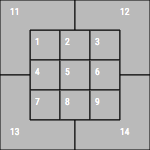

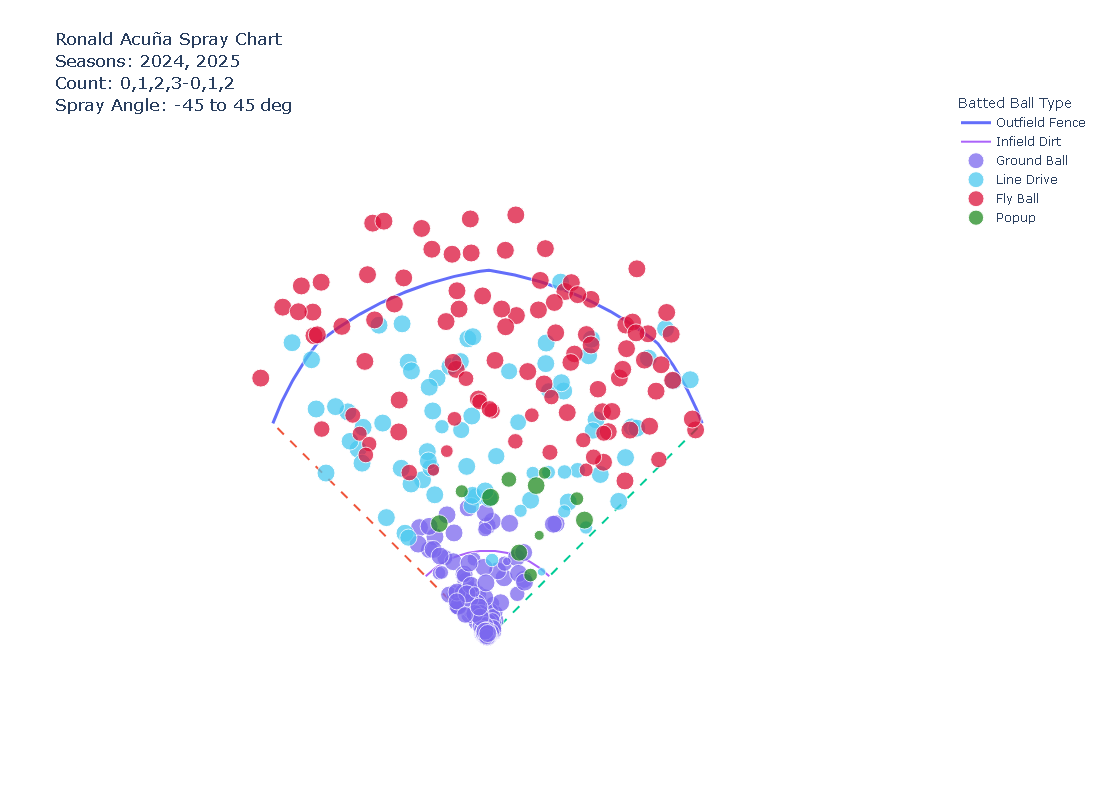

Batted balls: 353 | BA: 0.400 | xBA: 0.373 | xWOBA: 0.470 | Avg EV: 93.0 | EV50: 104.6 | Median LA: 10.0 deg | Median Contact Out In Front: 31.3 in | Median Attack Angle: 12.3 deg | Median Attack Direction: 5.4 deg | Median Swing Path Tilt: 37.2 deg | Median Bat Speed: 77.1 mph | Median Swing Length: 7.6 ft | Squared-Up Rate >= 80%: 63.3%


In [21]:

# Use df_all for both years, df_2025 for 2025 only, or df_2024 for 2024 only.
fig = make_spray_chart(
    df_all,
    player=player_to_chart,
    balls=[0, 1, 2, 3],
    strikes=[0,1,2],
    spray_angle_range=(-45,45)
)


## Leaderboard

Use the dropdowns to filter the leaderboard. For the composite AND metric, choose a metric-direction from the AND dropdown, click Add, and remove items from the compact Selected dropdown when needed.


In [44]:

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from pathlib import Path
from datetime import datetime

ZONE_MIRROR = {
    1: 3, 3: 1,
    4: 6, 6: 4,
    7: 9, 9: 7,
    11: 12, 12: 11,
    13: 14, 14: 13,
    2: 2, 5: 5, 8: 8,
}

LEADERBOARD_METRICS = {
    "BA": {"kind": "ba", "decimals": 3},
    "xBA": {"kind": "mean", "column": "estimated_ba_using_speedangle", "decimals": 3},
    "xWOBA": {"kind": "mean", "column": "estimated_woba_using_speedangle", "decimals": 3},
    "Avg EV": {"kind": "mean", "column": "launch_speed", "decimals": 1},
    "EV50": {"kind": "ev50", "column": "launch_speed", "decimals": 1},
    "Median LA": {"kind": "median", "column": "launch_angle", "decimals": 1},
    "Contact Out In Front": {"kind": "median", "column": "intercept_ball_minus_batter_pos_y_inches", "decimals": 1},
    "Attack Angle": {"kind": "median", "column": "attack_angle", "decimals": 1},
    "Attack Direction": {"kind": "median", "column": "attack_direction", "decimals": 1},
    "Swing Path Tilt": {"kind": "median", "column": "swing_path_tilt", "decimals": 1},
    "Bat Speed": {"kind": "median", "column": "bat_speed", "decimals": 1},
    "Swing Length": {"kind": "median", "column": "swing_length", "decimals": 1},
    "Squared-Up Rate": {"kind": "squared_up_rate", "decimals": 1},
    "Composite Percentile": {"kind": "composite", "decimals": 1},
}

HIT_EVENTS = {"single", "double", "triple", "home_run"}
OUT_EVENTS = {
    "field_out",
    "force_out",
    "grounded_into_double_play",
    "double_play",
    "fielders_choice_out",
    "fielders_choice",
    "other_out",
}
RESULT_GROUPS = {
    "All": None,
    "Hits": {"events": HIT_EVENTS},
    "Outs": {"events": OUT_EVENTS},
    "Home Runs": {"events": {"home_run"}},
    "Extra-Base Hits": {"events": {"double", "triple", "home_run"}},
    "Non-HR": {"exclude_events": {"home_run"}},
    "Ground Balls": {"bb_type": {"ground_ball"}},
    "Line Drives": {"bb_type": {"line_drive"}},
    "Fly Balls": {"bb_type": {"fly_ball"}},
    "Popups": {"bb_type": {"popup"}},
}
LAST_LEADERBOARD = {"high": pd.DataFrame(), "low": pd.DataFrame(), "all": pd.DataFrame(), "context": {}}


def _as_list(value):
    if value is None:
        return None
    if isinstance(value, str):
        text = value.strip()
        if not text or text.lower() == "all":
            return None
        return [v.strip() for v in text.replace(";", ",").split(",") if v.strip()]
    if isinstance(value, (list, tuple, set, pd.Series, np.ndarray)):
        values = list(value)
        return values if values else None
    return [value]


def _parse_int_list(value):
    values = _as_list(value)
    if values is None:
        return None
    parsed = []
    for item in values:
        if item is None or str(item).strip() == "":
            continue
        parsed.append(int(item))
    return parsed or None


def _apply_zone_filter(data, zones, mirror_zones=True):
    zone_values = _parse_int_list(zones)
    if zone_values is None:
        return data.copy(), None, None

    lefty_zones = set(zone_values)
    righty_zones = {ZONE_MIRROR.get(z, z) for z in lefty_zones} if mirror_zones else lefty_zones

    stand = data["stand"].astype(str).str.upper()
    mask = (
        (stand.eq("L") & data["zone"].isin(lefty_zones)) |
        (stand.eq("R") & data["zone"].isin(righty_zones))
    )
    return data[mask].copy(), sorted(lefty_zones), sorted(righty_zones)


def _apply_result_group_filter(data, result_group="All"):
    if result_group is None or str(result_group).lower() == "all":
        return data
    if result_group not in RESULT_GROUPS:
        raise ValueError(f"result_group must be one of: {', '.join(RESULT_GROUPS)}")
    rule = RESULT_GROUPS[result_group]
    if rule is None:
        return data
    out = data
    if "events" in rule:
        out = out[out["events"].isin(rule["events"])]
    if "exclude_events" in rule:
        out = out[~out["events"].isin(rule["exclude_events"])]
    if "bb_type" in rule:
        out = out[out["bb_type"].isin(rule["bb_type"])]
    return out


def _add_squared_up_columns(data, squared_up_threshold=80):
    out = data.copy()
    required = ["launch_speed", "bat_speed", "release_speed"]
    if not all(col in out.columns for col in required):
        out["squared_up_pct"] = np.nan
        out["is_squared_up"] = pd.NA
        return out

    launch_speed = pd.to_numeric(out["launch_speed"], errors="coerce")
    bat_speed = pd.to_numeric(out["bat_speed"], errors="coerce")
    release_speed = pd.to_numeric(out["release_speed"], errors="coerce")
    pitch_speed_home_proxy = 0.92 * release_speed
    max_theoretical_ev = 1.23 * bat_speed + 0.23 * pitch_speed_home_proxy
    out["squared_up_pct"] = launch_speed / max_theoretical_ev
    out.loc[max_theoretical_ev.le(0), "squared_up_pct"] = np.nan
    squared_up_cutoff = float(squared_up_threshold) / 100
    out["is_squared_up"] = pd.Series(
        np.where(out["squared_up_pct"].notna(), out["squared_up_pct"].ge(squared_up_cutoff), pd.NA),
        index=out.index,
        dtype="object"
    )
    return out


def _add_spray_angle_columns(data):
    out = data.copy()
    home_x = 125.42
    home_y = 198.27
    dx = out["hc_x"] - home_x
    dy = home_y - out["hc_y"]
    out["spray_angle"] = np.degrees(np.arctan2(dx, dy))

    stand = out["stand"].astype(str).str.upper()
    out["normalized_spray_angle"] = np.where(stand.eq("L"), -out["spray_angle"], out["spray_angle"])
    out["spray_side"] = np.select(
        [out["normalized_spray_angle"] < 0, out["normalized_spray_angle"] > 0],
        ["Pull", "Oppo"],
        default="Straightaway"
    )
    return out


def _apply_spray_angle_range(data, spray_angle_range=(-45, 45)):
    if spray_angle_range is None:
        return data, None
    if len(spray_angle_range) != 2:
        raise ValueError("spray_angle_range must be a two-value tuple/list like (-45, 45)")
    lo, hi = sorted([float(spray_angle_range[0]), float(spray_angle_range[1])])
    out = data[data["normalized_spray_angle"].between(lo, hi, inclusive="both")].copy()
    return out, (lo, hi)


def _ev50(values):
    ev_values = pd.to_numeric(values, errors="coerce").dropna().sort_values(ascending=False)
    ev50_count = int(np.ceil(len(ev_values) / 2))
    return ev_values.head(ev50_count).mean() if ev50_count > 0 else np.nan


def _parse_composite_formula(formula):
    if formula is None:
        raise ValueError("Choose at least one metric-direction pair for the composite.")

    if isinstance(formula, (list, tuple, set, pd.Series, np.ndarray)):
        raw_parts = [str(part).strip() for part in formula if str(part).strip()]
    else:
        text = str(formula).strip()
        if not text:
            raise ValueError("Choose at least one metric-direction pair for the composite.")
        raw_parts = [part.strip() for part in text.split(",") if part.strip()]

    parsed = []
    for part in raw_parts:
        if ":" not in part:
            raise ValueError(f"Composite part needs ':high' or ':low': {part}")
        metric_name, direction = part.rsplit(":", 1)
        metric_name = metric_name.strip()
        direction = direction.strip().lower()
        if metric_name not in LEADERBOARD_METRICS or metric_name == "Composite Percentile":
            raise ValueError(f"Unknown composite metric: {metric_name}")
        if direction in ["high", "higher", "highest", "desc", "max"]:
            direction = "high"
        elif direction in ["low", "lower", "lowest", "asc", "min"]:
            direction = "low"
        else:
            raise ValueError(f"Direction must be high or low for {metric_name}")
        parsed.append((metric_name, direction))
    if not parsed:
        raise ValueError("Composite formula did not include any metrics.")
    return parsed


def _metric_values_for_groups(metric_name, sub, grouped, squared_up_threshold=80):
    metric_info = LEADERBOARD_METRICS[metric_name]
    keys = ["batter", "batter_name", "stand"]

    if metric_info["kind"] == "ba":
        hits = grouped["events"].apply(lambda s: s.isin(HIT_EVENTS).sum()).reset_index(name="hits")
        outs = grouped["events"].apply(lambda s: s.isin(OUT_EVENTS).sum()).reset_index(name="outs")
        values = hits.merge(outs, on=keys, how="left")
        values["ab"] = values["hits"] + values["outs"]
        values[metric_name] = np.where(values["ab"] > 0, values["hits"] / values["ab"], np.nan)
        return values[keys + [metric_name]]

    if metric_info["kind"] == "squared_up_rate":
        squared = _add_squared_up_columns(sub, squared_up_threshold=squared_up_threshold)
        squared_grouped = squared.groupby(keys, dropna=False)
        return squared_grouped["is_squared_up"].apply(
            lambda s: s.dropna().mean() * 100 if s.notna().any() else np.nan
        ).reset_index(name=metric_name)

    col = metric_info.get("column")
    if col not in sub.columns:
        return grouped.size().reset_index(name=metric_name).assign(**{metric_name: np.nan})
    if metric_info["kind"] == "mean":
        return grouped[col].mean().reset_index(name=metric_name)
    if metric_info["kind"] == "median":
        return grouped[col].median().reset_index(name=metric_name)
    if metric_info["kind"] == "ev50":
        return grouped[col].apply(_ev50).reset_index(name=metric_name)
    raise ValueError(f"Composite does not support metric kind: {metric_info['kind']}")


def make_metric_leaderboard(
    data,
    metric="xWOBA",
    balls=None,
    strikes=None,
    pitch_bucket=None,
    pitch_name=None,
    zones=None,
    p_throws="All",
    result_group="All",
    spray_angle_range=(-45, 45),
    squared_up_threshold=80,
    composite_formula=None,
    min_batted_balls=25,
    top_n=15,
    mirror_zones=True,
):
    sub = data.copy()

    # Match the spray-chart population: batted balls with usable plotted contact data.
    sub = sub[
        sub["batter_name"].notna() &
        sub["stand"].notna() &
        sub["bb_type"].notna() &
        sub["hc_x"].notna() &
        sub["hc_y"].notna() &
        sub["hit_distance_sc"].notna()
    ].copy()
    sub = _add_spray_angle_columns(sub)
    sub, applied_spray_range = _apply_spray_angle_range(sub, spray_angle_range=spray_angle_range)

    p_throw_values = _as_list(p_throws)
    if p_throw_values is not None:
        sub = sub[sub["p_throws"].isin(p_throw_values)]

    sub = _apply_result_group_filter(sub, result_group=result_group)

    ball_values = _parse_int_list(balls)
    if ball_values is not None:
        sub = sub[sub["balls"].isin(ball_values)]

    strike_values = _parse_int_list(strikes)
    if strike_values is not None:
        sub = sub[sub["strikes"].isin(strike_values)]

    pitch_bucket_values = _as_list(pitch_bucket)
    if pitch_bucket_values is not None:
        sub = sub[sub["pitch_bucket"].isin(pitch_bucket_values)]

    pitch_name_values = _as_list(pitch_name)
    if pitch_name_values is not None:
        sub = sub[sub["pitch_name"].isin(pitch_name_values)]

    sub, lefty_zones, righty_zones = _apply_zone_filter(sub, zones, mirror_zones=mirror_zones)

    if sub.empty:
        return pd.DataFrame(), pd.DataFrame(), {
            "sample": 0,
            "lefty_zones": lefty_zones,
            "righty_zones": righty_zones,
            "spray_angle_range": applied_spray_range,
            "ranked_high": pd.DataFrame(),
            "ranked_low": pd.DataFrame(),
        }

    metric_info = LEADERBOARD_METRICS[metric]
    grouped = sub.groupby(["batter", "batter_name", "stand"], dropna=False)

    leaderboard = grouped.size().reset_index(name="batted_balls")

    if metric_info["kind"] == "composite":
        composite_parts = _parse_composite_formula(composite_formula)
        component_pct_cols = []
        for component_metric, direction in composite_parts:
            values = _metric_values_for_groups(component_metric, sub, grouped, squared_up_threshold=squared_up_threshold)
            value_col = f"{component_metric} Value"
            pct_col = f"{component_metric} %ile ({direction})"
            values = values.rename(columns={component_metric: value_col})
            leaderboard = leaderboard.merge(values, on=["batter", "batter_name", "stand"], how="left")
            ascending = True if direction == "high" else False
            leaderboard[pct_col] = leaderboard[value_col].rank(pct=True, ascending=ascending) * 100
            component_pct_cols.append(pct_col)
        leaderboard[metric] = leaderboard[component_pct_cols].mean(axis=1, skipna=False)
    elif metric_info["kind"] == "ba":
        hits = grouped["events"].apply(lambda s: s.isin(HIT_EVENTS).sum()).reset_index(name="hits")
        outs = grouped["events"].apply(lambda s: s.isin(OUT_EVENTS).sum()).reset_index(name="outs")
        leaderboard = leaderboard.merge(hits, on=["batter", "batter_name", "stand"], how="left")
        leaderboard = leaderboard.merge(outs, on=["batter", "batter_name", "stand"], how="left")
        leaderboard["ab"] = leaderboard["hits"] + leaderboard["outs"]
        leaderboard[metric] = np.where(leaderboard["ab"] > 0, leaderboard["hits"] / leaderboard["ab"], np.nan)
    elif metric_info["kind"] == "squared_up_rate":
        sub = _add_squared_up_columns(sub, squared_up_threshold=squared_up_threshold)
        grouped = sub.groupby(["batter", "batter_name", "stand"], dropna=False)
        valid_counts = grouped["is_squared_up"].apply(lambda s: s.notna().sum()).reset_index(name="valid_squared_up_bbes")
        values = grouped["is_squared_up"].apply(lambda s: s.dropna().mean() * 100 if s.notna().any() else np.nan).reset_index(name=metric)
        leaderboard = leaderboard.merge(valid_counts, on=["batter", "batter_name", "stand"], how="left")
        leaderboard = leaderboard.merge(values, on=["batter", "batter_name", "stand"], how="left")
    else:
        col = metric_info["column"]
        if col not in sub.columns:
            leaderboard[metric] = np.nan
        elif metric_info["kind"] == "mean":
            values = grouped[col].mean().reset_index(name=metric)
            leaderboard = leaderboard.merge(values, on=["batter", "batter_name", "stand"], how="left")
        elif metric_info["kind"] == "median":
            values = grouped[col].median().reset_index(name=metric)
            leaderboard = leaderboard.merge(values, on=["batter", "batter_name", "stand"], how="left")
        elif metric_info["kind"] == "ev50":
            values = grouped[col].apply(_ev50).reset_index(name=metric)
            leaderboard = leaderboard.merge(values, on=["batter", "batter_name", "stand"], how="left")
        else:
            raise ValueError(f"Unknown metric kind: {metric_info['kind']}")

    min_sample_col = "valid_squared_up_bbes" if metric_info["kind"] == "squared_up_rate" else "batted_balls"
    leaderboard = leaderboard[
        (leaderboard[min_sample_col] >= int(min_batted_balls)) &
        leaderboard[metric].notna()
    ].copy()

    if leaderboard.empty:
        return leaderboard, leaderboard, {
            "sample": len(sub),
            "lefty_zones": lefty_zones,
            "righty_zones": righty_zones,
            "spray_angle_range": applied_spray_range,
            "ranked_high": leaderboard,
            "ranked_low": leaderboard,
        }

    display_cols = ["batter_name", "stand", "batted_balls", metric]
    if metric == "BA":
        display_cols.extend(["hits", "ab"])
    if metric_info["kind"] == "squared_up_rate":
        display_cols.insert(3, "valid_squared_up_bbes")
    if metric_info["kind"] == "composite":
        display_cols.extend([col for col in leaderboard.columns if "%ile" in col])

    ranked_high = leaderboard.sort_values([metric, "batted_balls"], ascending=[False, False])[display_cols].reset_index(drop=True)
    ranked_low = leaderboard.sort_values([metric, "batted_balls"], ascending=[True, False])[display_cols].reset_index(drop=True)

    ranked_high.insert(0, "rank", np.arange(1, len(ranked_high) + 1))
    ranked_low.insert(0, "rank", np.arange(1, len(ranked_low) + 1))

    decimals = metric_info["decimals"]
    for table in (ranked_high, ranked_low):
        table[metric] = table[metric].round(decimals)
        for pct_col in [col for col in table.columns if "%ile" in col]:
            table[pct_col] = table[pct_col].round(1)

    high = ranked_high.head(top_n).copy()
    low = ranked_low.head(top_n).copy()

    return high, low, {
        "sample": len(sub),
        "lefty_zones": lefty_zones,
        "righty_zones": righty_zones,
        "spray_angle_range": applied_spray_range,
        "ranked_high": ranked_high,
        "ranked_low": ranked_low,
    }


def _leaderboard_pitch_names(data):
    names = data["pitch_name"].dropna().sort_values().unique().tolist()
    return ["All"] + names


def _leaderboard_dataframes():
    return {
        "2024 + 2025": df_all,
        "2025": df_2025,
        "2024": df_2024,
    }


def export_latest_leaderboard_html(export_dir=r"E:\Baseball\Exports"):
    high = LAST_LEADERBOARD.get("high", pd.DataFrame())
    low = LAST_LEADERBOARD.get("low", pd.DataFrame())
    if high.empty and low.empty:
        raise ValueError("No leaderboard results to export yet. Run the leaderboard first.")
    export_path = Path(export_dir)
    export_path.mkdir(parents=True, exist_ok=True)
    path = export_path / f"leaderboard_{datetime.now().strftime('%Y%m%d_%H%M%S')}.html"
    context = LAST_LEADERBOARD.get("context", {})
    context_html = "".join(f"<li><b>{k}</b>: {v}</li>" for k, v in context.items())
    html = f"""
    <html><head><meta charset='utf-8'><title>Spray Metric Leaderboard</title></head>
    <body>
    <h2>Spray Metric Leaderboard</h2>
    <ul>{context_html}</ul>
    <h3>Highest</h3>{high.to_html(index=False)}
    <h3>Lowest</h3>{low.to_html(index=False)}
    </body></html>
    """
    path.write_text(html, encoding="utf-8")
    print(f"Saved leaderboard HTML: {path}")
    return path


def _composite_metric_options():
    options = []
    for metric_name in LEADERBOARD_METRICS:
        if metric_name == "Composite Percentile":
            continue
        options.append((f"{metric_name} - high", f"{metric_name}:high"))
        options.append((f"{metric_name} - low", f"{metric_name}:low"))
    return options


season_widget = widgets.Dropdown(
    options=["2024 + 2025", "2025", "2024"],
    value="2024 + 2025",
    description="Season",
)
metric_widget = widgets.Dropdown(
    options=list(LEADERBOARD_METRICS.keys()),
    value="xWOBA",
    description="Metric",
)
balls_widget = widgets.SelectMultiple(
    options=[0, 1, 2, 3],
    value=(0, 1, 2, 3),
    description="Balls",
)
strikes_widget = widgets.SelectMultiple(
    options=[0, 1, 2],
    value=(0, 1, 2),
    description="Strikes",
)
pitch_bucket_widget = widgets.Dropdown(
    options=["All", "Fastball", "Offspeed", "Breaking"],
    value="Fastball",
    description="Group",
)
pitch_name_widget = widgets.Dropdown(
    options=_leaderboard_pitch_names(df_all),
    value="All",
    description="Pitch",
)
p_throws_widget = widgets.Dropdown(
    options=["All", "R", "L"],
    value="All",
    description="P Throws",
)
result_group_widget = widgets.Dropdown(
    options=list(RESULT_GROUPS.keys()),
    value="All",
    description="Result",
)
spray_min_widget = widgets.BoundedFloatText(
    value=-45,
    min=-45,
    max=45,
    step=1,
    description="Spray Min",
)
spray_max_widget = widgets.BoundedFloatText(
    value=45,
    min=-45,
    max=45,
    step=1,
    description="Spray Max",
)
zones_widget = widgets.Text(
    value="3,6,9",
    description="Zones",
    placeholder="Example: 3,6,9",
)
min_batted_balls_widget = widgets.BoundedIntText(
    value=25,
    min=1,
    max=1000,
    step=1,
    description="Min BBEs",
)
top_n_widget = widgets.BoundedIntText(
    value=15,
    min=1,
    max=50,
    step=1,
    description="Rows",
)
squared_up_threshold_widget = widgets.BoundedFloatText(
    value=80,
    min=0,
    max=120,
    step=1,
    description="Sq Up %",
)
player_search_widget = widgets.Text(
    value="",
    description="Find Player",
    placeholder="Type a name, e.g. Soto",
    layout=widgets.Layout(width="260px"),
)
player_search_button = widgets.Button(description="Search", layout=widgets.Layout(width="80px"))
clear_player_search_button = widgets.Button(description="Clear", layout=widgets.Layout(width="70px"))
player_search_results = widgets.HTML(layout=widgets.Layout(width="auto"))

COMPOSITE_SELECTIONS = ["EV50:high", "Squared-Up Rate:high", "Swing Length:low"]

composite_metric_dropdown = widgets.Dropdown(
    options=_composite_metric_options(),
    value="EV50:high",
    description="AND",
    layout=widgets.Layout(width="270px"),
)
add_composite_button = widgets.Button(description="Add", layout=widgets.Layout(width="70px"))
selected_composite_dropdown = widgets.Dropdown(
    options=COMPOSITE_SELECTIONS,
    value=COMPOSITE_SELECTIONS[0],
    description="Selected",
    layout=widgets.Layout(width="330px"),
)
remove_composite_button = widgets.Button(description="Remove", layout=widgets.Layout(width="90px"))
clear_composite_button = widgets.Button(description="Clear", layout=widgets.Layout(width="70px"))
composite_summary = widgets.HTML()

export_leaderboard_button = widgets.Button(description="Export Leaderboard HTML")
leaderboard_output = widgets.Output()
export_output = widgets.Output()


def _composite_formula_value():
    return tuple(COMPOSITE_SELECTIONS)


def _composite_formula_display_text():
    return ", ".join(COMPOSITE_SELECTIONS)


def _refresh_composite_controls():
    selected_composite_dropdown.options = tuple(COMPOSITE_SELECTIONS)
    selected_composite_dropdown.value = COMPOSITE_SELECTIONS[0] if COMPOSITE_SELECTIONS else None
    text = _composite_formula_display_text() if COMPOSITE_SELECTIONS else "None selected"
    composite_summary.value = f"<span style='font-size:12px;'>Composite AND: {text}</span>"


def _add_composite_metric(_):
    value = composite_metric_dropdown.value
    if value and value not in COMPOSITE_SELECTIONS:
        COMPOSITE_SELECTIONS.append(value)
        _refresh_composite_controls()
        update_metric_leaderboard()


def _remove_composite_metric(_):
    value = selected_composite_dropdown.value
    if value in COMPOSITE_SELECTIONS:
        COMPOSITE_SELECTIONS.remove(value)
        _refresh_composite_controls()
        update_metric_leaderboard()


def _clear_composite_metrics(_):
    COMPOSITE_SELECTIONS.clear()
    _refresh_composite_controls()
    update_metric_leaderboard()


_refresh_composite_controls()


def update_metric_leaderboard(*_):
    with leaderboard_output:
        clear_output(wait=True)
        data = _leaderboard_dataframes()[season_widget.value]
        pitch_bucket = None if pitch_bucket_widget.value == "All" else pitch_bucket_widget.value
        pitch_name = None if pitch_name_widget.value == "All" else pitch_name_widget.value
        spray_range = (spray_min_widget.value, spray_max_widget.value)

        try:
            high, low, info = make_metric_leaderboard(
                data,
                metric=metric_widget.value,
                balls=list(balls_widget.value),
                strikes=list(strikes_widget.value),
                pitch_bucket=pitch_bucket,
                pitch_name=pitch_name,
                zones=zones_widget.value,
                p_throws=p_throws_widget.value,
                result_group=result_group_widget.value,
                spray_angle_range=spray_range,
                squared_up_threshold=squared_up_threshold_widget.value,
                composite_formula=_composite_formula_value(),
                min_batted_balls=min_batted_balls_widget.value,
                top_n=top_n_widget.value,
                mirror_zones=True,
            )
        except Exception as exc:
            display(HTML(f"<b>Leaderboard error:</b> {exc}"))
            return

        zone_note = "All zones"
        if info["lefty_zones"] is not None:
            zone_note = f"LHH zones: {info['lefty_zones']} | RHH mirrored zones: {info['righty_zones']}"

        sample_note = "Minimum batted balls per hitter"
        if metric_widget.value == "Squared-Up Rate":
            sample_note = "Minimum valid squared-up tracked BBEs per hitter"

        context = {
            "Season": season_widget.value,
            "Metric": metric_widget.value,
            "Balls": list(balls_widget.value),
            "Strikes": list(strikes_widget.value),
            "Pitch Group": pitch_bucket_widget.value,
            "Pitch": pitch_name_widget.value,
            "Pitcher Throws": p_throws_widget.value,
            "Result": result_group_widget.value,
            "Spray Angle": f"{min(spray_range):.0f} to {max(spray_range):.0f} deg",
            "Squared-Up Threshold": f"{squared_up_threshold_widget.value:.0f}%",
            "Composite Formula": _composite_formula_display_text() if metric_widget.value == "Composite Percentile" else "",
            "Zones": zone_note,
            "Minimum": min_batted_balls_widget.value,
        }
        LAST_LEADERBOARD["high"] = high
        LAST_LEADERBOARD["low"] = low
        LAST_LEADERBOARD["all"] = info.get("ranked_high", pd.DataFrame())
        LAST_LEADERBOARD["context"] = context

        display(HTML(
            f"<b>{metric_widget.value} Leaderboard</b><br>"
            f"Filtered batted balls before player minimum: {info['sample']:,}<br>"
            f"Pitcher throws: {p_throws_widget.value}<br>"
            f"Result: {result_group_widget.value}<br>"
            f"Spray angle: {min(spray_range):.0f} to {max(spray_range):.0f} deg<br>"
            f"Squared-up threshold: {squared_up_threshold_widget.value:.0f}%<br>"
            f"{'Composite formula: ' + _composite_formula_display_text() + '<br>' if metric_widget.value == 'Composite Percentile' else ''}"
            f"{zone_note}<br>"
            f"{sample_note}: {min_batted_balls_widget.value}"
        ))

        display(player_search_panel)
        _update_player_search()

        if high.empty and low.empty:
            display(HTML("<br><b>No players match these filters.</b>"))
            return

        display(HTML("<h4>Highest</h4>"))
        display(high)
        display(HTML("<h4>Lowest</h4>"))
        display(low)


def _update_player_search(*_):
    query = player_search_widget.value.strip()
    if not query:
        player_search_results.value = "<b>Player Search</b><br>Type a player name to see his row from the current filtered leaderboard."
        return

    table = LAST_LEADERBOARD.get("all", pd.DataFrame())
    if table.empty:
        player_search_results.value = "<b>Player Search</b><br>No leaderboard rows match the current filters."
        return

    matches = table[table["batter_name"].astype(str).str.contains(query, case=False, na=False)].copy()
    if matches.empty:
        player_search_results.value = f"<b>Player Search</b><br>No match for <code>{query}</code> with the current filters/minimum."
        return

    table_html = matches.head(12).to_html(index=False, border=0)
    player_search_results.value = f"<b>Player Search</b><br>{len(matches)} match(es) from the current filtered leaderboard.<br>{table_html}"


def _clear_player_search(_):
    player_search_widget.value = ""
    _update_player_search()


def _export_leaderboard_clicked(_):
    with export_output:
        export_output.clear_output(wait=True)
        try:
            export_latest_leaderboard_html()
        except Exception as exc:
            print(f"Export failed: {exc}")


def _refresh_pitch_name_options(*_):
    data = _leaderboard_dataframes()[season_widget.value]
    current = pitch_name_widget.value
    options = _leaderboard_pitch_names(data)
    pitch_name_widget.options = options
    pitch_name_widget.value = current if current in options else "All"


for control in [
    season_widget,
    metric_widget,
    balls_widget,
    strikes_widget,
    pitch_bucket_widget,
    pitch_name_widget,
    p_throws_widget,
    result_group_widget,
    spray_min_widget,
    spray_max_widget,
    zones_widget,
    min_batted_balls_widget,
    top_n_widget,
    squared_up_threshold_widget,
]:
    control.observe(update_metric_leaderboard, names="value")

season_widget.observe(_refresh_pitch_name_options, names="value")
player_search_widget.observe(_update_player_search, names="value")
player_search_button.on_click(_update_player_search)
clear_player_search_button.on_click(_clear_player_search)
add_composite_button.on_click(_add_composite_metric)
remove_composite_button.on_click(_remove_composite_metric)
clear_composite_button.on_click(_clear_composite_metrics)
export_leaderboard_button.on_click(_export_leaderboard_clicked)

row_layout = widgets.Layout(display="flex", flex_flow="row wrap", align_items="flex-start", width="100%")
compact_row_layout = widgets.Layout(display="flex", flex_flow="row wrap", align_items="center", width="100%")

filter_controls = widgets.VBox([
    widgets.HBox([season_widget, metric_widget, min_batted_balls_widget, top_n_widget, squared_up_threshold_widget], layout=row_layout),
    widgets.HBox([balls_widget, strikes_widget, pitch_bucket_widget, pitch_name_widget], layout=row_layout),
    widgets.HBox([p_throws_widget, result_group_widget, spray_min_widget, spray_max_widget], layout=row_layout),
    widgets.HBox([composite_metric_dropdown, add_composite_button, selected_composite_dropdown, remove_composite_button, clear_composite_button], layout=row_layout),
    composite_summary,
    zones_widget,
    widgets.HBox([export_leaderboard_button, export_output], layout=compact_row_layout),
], layout=widgets.Layout(width="100%"))

player_search_panel = widgets.VBox([
    widgets.HTML("<b>Player Lookup</b>"),
    widgets.HBox([player_search_widget, player_search_button, clear_player_search_button], layout=compact_row_layout),
    player_search_results,
], layout=widgets.Layout(margin="18px 0 0 0", width="100%"))

controls = widgets.VBox([
    filter_controls,
], layout=widgets.Layout(width="100%"))

display(controls, leaderboard_output)
update_metric_leaderboard()


Output()

## Notes

- `Sq Up %` changes the squared-up threshold used by the chart and leaderboard. Doesn't make a difference unless you are evaluating `Squared-Up Rate` as one of the metrics.
- To look at multiple metrics, select `Composite Score` from Metric section, and select what you would like to add in the `AND` dropdown
- `Zones` are entered from the left-handed hitter view and mirror automatically for right-handed hitters.
